# SAR Ship Detection: YOLOv8 vs RT-DETR
**CS231n Project — All-Weather Ship Detection in SAR Imagery**

This notebook:
1. Installs dependencies
2. Downloads and prepares HRSID + SSDD datasets
3. Converts annotations to YOLO format
4. Trains YOLOv8 baseline
5. Trains RT-DETR (our novel model)
6. Evaluates and compares both models
7. Visualizes predictions

## 0. Check GPU

In [1]:
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')
!nvidia-smi

CUDA available: True
GPU: Tesla T4
Thu May 28 22:20:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------

## 1. Install Dependencies

In [2]:
!pip install ultralytics==8.3.0 -q
!pip install pycocotools -q
!pip install gdown -q

import ultralytics
ultralytics.checks()

Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


## 2. Mount Google Drive (to save checkpoints)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/cs231n_sar'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Checkpoints will be saved to: {SAVE_DIR}')

Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/cs231n_sar


## 3. Download HRSID Dataset

HRSID is hosted on GitHub. We download the annotations (COCO format) and images.
- 5,604 SAR images (800x800)
- 16,951 ship instances
- Source: Wei et al., IEEE Access 2020

In [5]:
import os

# Create dataset directory structure
os.makedirs('/content/datasets/HRSID/images', exist_ok=True)
os.makedirs('/content/datasets/HRSID/annotations', exist_ok=True)

# Clone the HRSID repo (contains annotations + download links)
!git clone https://github.com/chaozhong2010/HRSID.git /content/HRSID_repo

# Copy annotations
!cp /content/HRSID_repo/annotations/*.json /content/datasets/HRSID/annotations/

print('Annotation files:')
!ls /content/datasets/HRSID/annotations/

Cloning into '/content/HRSID_repo'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 128 (delta 61), reused 128 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 7.85 MiB | 19.85 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Annotation files:
train2017.json


In [10]:
# Download HRSID dataset (updated link from official repo)

import gdown
import os

os.makedirs("/content/datasets/HRSID", exist_ok=True)

file_id = "1NY3ovgc-woDlNoQdyqzRB3t9McOBH5Ms"
output = "/content/datasets/HRSID/HRSID.zip"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    output,
    quiet=False,
    fuzzy=True
)

!unzip -q $output -d /content/datasets/HRSID/

print("Done.")

Downloading...
From (original): https://drive.google.com/uc?id=1NY3ovgc-woDlNoQdyqzRB3t9McOBH5Ms
From (redirected): https://drive.google.com/uc?id=1NY3ovgc-woDlNoQdyqzRB3t9McOBH5Ms&confirm=t&uuid=43038594-6907-42a3-b0f7-deb40eba79a9
To: /content/datasets/HRSID/HRSID.zip
100%|██████████| 614M/614M [00:06<00:00, 89.6MB/s]


Done.


In [12]:
!find /content/datasets/HRSID -type f | head -50

/content/datasets/HRSID/annotations/train2017.json
/content/datasets/HRSID/HRSID.zip
/content/datasets/HRSID/HRSID_JPG/inshore_offshore/inshore.json
/content/datasets/HRSID/HRSID_JPG/inshore_offshore/offshore.json
/content/datasets/HRSID/HRSID_JPG/annotations/test2017.json
/content/datasets/HRSID/HRSID_JPG/annotations/train2017.json
/content/datasets/HRSID/HRSID_JPG/annotations/train_test2017.json
/content/datasets/HRSID/HRSID_JPG/JPEGImages/P0025_0_800_9600_10400.jpg
/content/datasets/HRSID/HRSID_JPG/JPEGImages/P0075_0_800_1800_2600.jpg
/content/datasets/HRSID/HRSID_JPG/JPEGImages/P0029_2400_3200_4800_5600.jpg
/content/datasets/HRSID/HRSID_JPG/JPEGImages/P0003_1200_2000_4800_5600.jpg
/content/datasets/HRSID/HRSID_JPG/JPEGImages/P0047_600_1400_3000_3800.jpg
/content/datasets/HRSID/HRSID_JPG/JPEGImages/P0041_1200_2000_1800_2600.jpg
/content/datasets/HRSID/HRSID_JPG/JPEGImages/P0029_3600_4400_2400_3200.jpg
/content/datasets/HRSID/HRSID_JPG/JPEGImages/P0012_4800_5600_4800_5600.jpg
/conten

In [13]:
import json

ANN_PATH = "/content/datasets/HRSID/HRSID_JPG/annotations"

with open(f"{ANN_PATH}/train2017.json") as f:
    train_ann = json.load(f)

with open(f"{ANN_PATH}/test2017.json") as f:
    test_ann = json.load(f)

print(f"Train images: {len(train_ann['images'])}")
print(f"Train annotations: {len(train_ann['annotations'])}")

print(f"Test images: {len(test_ann['images'])}")
print(f"Test annotations: {len(test_ann['annotations'])}")

print(f"Categories: {train_ann['categories']}")

Train images: 3642
Train annotations: 11047
Test images: 1962
Test annotations: 5922
Categories: [{'supercategory': None, 'id': 1, 'name': 'ship'}]


In [14]:
import os

print("Train json exists:",
      os.path.exists("/content/datasets/HRSID/HRSID_JPG/annotations/train2017.json"))

print("Test json exists:",
      os.path.exists("/content/datasets/HRSID/HRSID_JPG/annotations/test2017.json"))

print("Images dir exists:",
      os.path.exists("/content/datasets/HRSID/HRSID_JPG/JPEGImages"))

print("Image count:",
      len(os.listdir("/content/datasets/HRSID/HRSID_JPG/JPEGImages")))

Train json exists: True
Test json exists: True
Images dir exists: True
Image count: 5604


## 4. Convert COCO Annotations → YOLO Format

Ultralytics models expect labels in YOLO format:
`class_id cx cy w h` (all normalized 0-1)

In [15]:
import json
import os
import shutil
from pathlib import Path

def coco_to_yolo(ann_file, images_src_dir, output_images_dir, output_labels_dir):
    """
    Convert COCO format annotations to YOLO format.
    Also copies images to the output directory.
    """
    os.makedirs(output_images_dir, exist_ok=True)
    os.makedirs(output_labels_dir, exist_ok=True)

    with open(ann_file) as f:
        data = json.load(f)

    # Build image id -> info mapping
    img_info = {img['id']: img for img in data['images']}

    # Build image id -> list of annotations
    ann_by_img = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        if img_id not in ann_by_img:
            ann_by_img[img_id] = []
        ann_by_img[img_id].append(ann)

    converted = 0
    skipped = 0

    for img_id, img in img_info.items():
        fname = img['file_name']
        w, h = img['width'], img['height']

        # Find source image - search recursively
        src_candidates = list(Path(images_src_dir).rglob(fname))
        if not src_candidates:
            skipped += 1
            continue
        src_path = src_candidates[0]

        # Copy image
        dst_img = os.path.join(output_images_dir, fname)
        shutil.copy2(str(src_path), dst_img)

        # Write YOLO label file
        label_fname = os.path.splitext(fname)[0] + '.txt'
        label_path = os.path.join(output_labels_dir, label_fname)

        annotations = ann_by_img.get(img_id, [])

        with open(label_path, 'w') as lf:
            for ann in annotations:
                # COCO bbox: [x_min, y_min, width, height]
                x_min, y_min, bw, bh = ann['bbox']

                # Convert to YOLO: cx cy w h (normalized)
                cx = (x_min + bw / 2) / w
                cy = (y_min + bh / 2) / h
                nw = bw / w
                nh = bh / h

                # Clamp to [0, 1]
                cx = max(0, min(1, cx))
                cy = max(0, min(1, cy))
                nw = max(0, min(1, nw))
                nh = max(0, min(1, nh))

                # Class 0 = ship (single class)
                lf.write(f'0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n')

        converted += 1

    print(f'Converted {converted} images, skipped {skipped} (image not found)')
    return converted


# Find where images actually are
print('Looking for images...')
jpg_files = list(Path('/content/datasets/HRSID').rglob('*.jpg'))
print(f'Found {len(jpg_files)} jpg files')
if jpg_files:
    print(f'Example: {jpg_files[0]}')
    IMAGE_SRC = str(jpg_files[0].parent)

Looking for images...
Found 5604 jpg files
Example: /content/datasets/HRSID/HRSID_JPG/JPEGImages/P0025_0_800_9600_10400.jpg


In [17]:
from pathlib import Path

# Correct dataset paths
DATASET_ROOT = '/content/datasets/HRSID_YOLO'
IMAGE_SRC = '/content/datasets/HRSID/HRSID_JPG/JPEGImages'

TRAIN_ANN = '/content/datasets/HRSID/HRSID_JPG/annotations/train2017.json'
TEST_ANN  = '/content/datasets/HRSID/HRSID_JPG/annotations/test2017.json'

print('Converting train split...')
coco_to_yolo(
    ann_file=TRAIN_ANN,
    images_src_dir=IMAGE_SRC,
    output_images_dir=f'{DATASET_ROOT}/images/train',
    output_labels_dir=f'{DATASET_ROOT}/labels/train'
)

print('\nConverting test split...')
coco_to_yolo(
    ann_file=TEST_ANN,
    images_src_dir=IMAGE_SRC,
    output_images_dir=f'{DATASET_ROOT}/images/val',
    output_labels_dir=f'{DATASET_ROOT}/labels/val'
)

print('\nDataset ready!')

print(
    f"Train images: "
    f"{len(list(Path(DATASET_ROOT + '/images/train').glob('*.jpg')))}"
)

print(
    f"Val images: "
    f"{len(list(Path(DATASET_ROOT + '/images/val').glob('*.jpg')))}"
)

print(
    f"Train labels: "
    f"{len(list(Path(DATASET_ROOT + '/labels/train').glob('*.txt')))}"
)

print(
    f"Val labels: "
    f"{len(list(Path(DATASET_ROOT + '/labels/val').glob('*.txt')))}"
)


Converting train split...
Converted 3642 images, skipped 0 (image not found)

Converting test split...
Converted 1962 images, skipped 0 (image not found)

Dataset ready!
Train images: 3642
Val images: 1962
Train labels: 3642
Val labels: 1962


## 5. Create Dataset YAML Config

In [18]:
import yaml

dataset_config = {
    'path': DATASET_ROOT,
    'train': 'images/train',
    'val': 'images/val',
    'nc': 1,
    'names': ['ship']
}

yaml_path = '/content/hrsid.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print('Dataset config saved:')
with open(yaml_path) as f:
    print(f.read())

Dataset config saved:
names:
- ship
nc: 1
path: /content/datasets/HRSID_YOLO
train: images/train
val: images/val



## 6. Visualize Sample Images
Always sanity check your data before training!

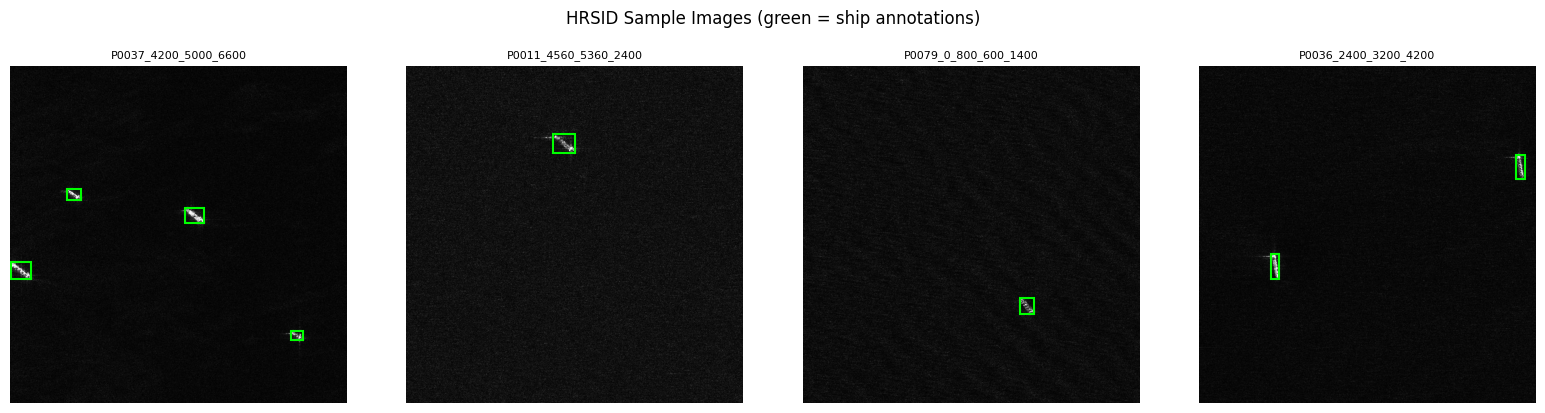

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random

def visualize_yolo_sample(images_dir, labels_dir, n=4):
    img_files = list(Path(images_dir).glob('*.jpg'))
    random.shuffle(img_files)
    samples = img_files[:n]

    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]

    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path)
        W, H = img.size
        ax.imshow(img, cmap='gray')

        # Load labels
        label_path = Path(labels_dir) / (img_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = map(float, parts)
                        x = (cx - bw/2) * W
                        y = (cy - bh/2) * H
                        rect = patches.Rectangle(
                            (x, y), bw*W, bh*H,
                            linewidth=1.5, edgecolor='lime', facecolor='none'
                        )
                        ax.add_patch(rect)

        ax.set_title(img_path.name[:20], fontsize=8)
        ax.axis('off')

    plt.suptitle('HRSID Sample Images (green = ship annotations)', y=1.02)
    plt.tight_layout()
    plt.show()

visualize_yolo_sample(
    f'{DATASET_ROOT}/images/train',
    f'{DATASET_ROOT}/labels/train',
    n=4
)

## 7. Train YOLOv8 Baseline

Vanilla YOLOv8n fine-tuned on HRSID with COCO pretrained weights.
This is our baseline — no SAR-specific architectural changes.

In [ ]:
# ===== FIX NUMPY / ULTRALYTICS ENV =====

!pip uninstall -y numpy ultralytics opencv-python opencv-contrib-python opencv-python-headless pycocotools

!pip install -q \
numpy==1.26.4 \
ultralytics \
opencv-python \
pycocotools

print("Environment fixed. Restarting runtime...")

import os
os.kill(os.getpid(), 9)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: ultralytics 8.3.0
Uninstalling ultralytics-8.3.0:
  Successfully uninstalled ultralytics-8.3.0
Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Successfully uninstalled opencv-python-4.11.0.86
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Found existing installation: pycocotools 2.0.11
Uninstalling pycocotools-2.0.11:
  Successfully uninstalled pycocotools-2.0.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.7/411.7 kB 35.7 MB/s eta 0:00:00
ERROR

In [2]:
from pathlib import Path
import yaml
from ultralytics import YOLO

# =========================
# Paths
# =========================

DATASET_ROOT = "/content/datasets/HRSID_YOLO"
SAVE_DIR = "/content/runs"

yaml_path = "/content/datasets/HRSID_YOLO/hrsid.yaml"

# =========================
# Recreate YOLO dataset yaml
# =========================

dataset_yaml = {
    "path": DATASET_ROOT,
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "ship"
    }
}

with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f)

print("YAML saved:", yaml_path)

# =========================
# Verify dataset exists
# =========================

train_imgs = len(list(Path(f"{DATASET_ROOT}/images/train").glob("*.jpg")))
val_imgs   = len(list(Path(f"{DATASET_ROOT}/images/val").glob("*.jpg")))

train_lbls = len(list(Path(f"{DATASET_ROOT}/labels/train").glob("*.txt")))
val_lbls   = len(list(Path(f"{DATASET_ROOT}/labels/val").glob("*.txt")))

print(f"Train images: {train_imgs}")
print(f"Val images:   {val_imgs}")
print(f"Train labels: {train_lbls}")
print(f"Val labels:   {val_lbls}")

# =========================
# Load model
# =========================

yolo_model = YOLO("yolov8n.pt")

# =========================
# Train
# =========================

results = yolo_model.train(
    data=yaml_path,
    epochs=100,
    imgsz=800,
    batch=8,
    device=0,
    workers=2,

    optimizer="AdamW",
    lr0=1e-3,
    lrf=0.01,
    warmup_epochs=3,
    weight_decay=5e-4,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.3,
    fliplr=0.5,
    flipud=0.3,
    degrees=15.0,
    mosaic=0.5,
    copy_paste=0.1,

    project=SAVE_DIR,
    name="yolov8n_hrsid",
    exist_ok=True,

    patience=20,
    save=True,
    plots=True,
    verbose=True
)

print("\nDone.")
print(f"Best weights: {SAVE_DIR}/yolov8n_hrsid/weights/best.pt")

YAML saved: /content/datasets/HRSID_YOLO/hrsid.yaml
Train images: 3642
Val images:   1962
Train labels: 3642
Val labels:   1962
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/HRSID_YOLO/hrsid.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mo

Exception ignored in: <generator object TQDM.__iter__ at 0x7fc40249aa80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tqdm.py", line 354, in __iter__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tqdm.py", line 323, in close
    self._display(final=True)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tqdm.py", line 253, in _display
    n_str = self._format_num(self.n)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/tqdm.py", line 171, in _format_num
    def _format_num(self, num: int | float) -> str:

KeyboardInterrupt: 
Process Process-3:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 337, in _exit_function
    _run_finalizers(0)
  File "/usr/lib/python3.12/multiprocess

KeyboardInterrupt: 

## 8. Evaluate YOLOv8 on Test Set

In [ ]:
# Load best checkpoint and evaluate
yolo_best = YOLO(f'{SAVE_DIR}/yolov8n_hrsid/weights/best.pt')

yolo_metrics = yolo_best.val(
    data=yaml_path,
    imgsz=800,
    batch=8,
    device=0,
    split='val',
    plots=True,
    save_json=True  # Saves COCO-format results
)

print('\n===== YOLOv8 Results =====')
print(f'mAP@50:    {yolo_metrics.box.map50:.4f}')
print(f'mAP@50-95: {yolo_metrics.box.map:.4f}')
print(f'Precision: {yolo_metrics.box.mp:.4f}')
print(f'Recall:    {yolo_metrics.box.mr:.4f}')

## 9. Train RT-DETR

RT-DETR (Real-Time Detection Transformer) — our novel model for this dataset.
Key differences from YOLOv8:
- Transformer encoder for global attention (better for arbitrary-oriented ships)
- No NMS post-processing (better for dense harbor scenes)
- Hybrid CNN-transformer backbone

In [6]:
from ultralytics import RTDETR

# Load pretrained RT-DETR
rtdetr_model = RTDETR("rtdetr-l.pt")

# Train
rtdetr_results = rtdetr_model.train(
    data=yaml_path,

    epochs=10,
    imgsz=800,
    batch=4,
    device=0,
    workers=2,

    optimizer="AdamW",
    lr0=1e-4,
    lrf=0.01,
    warmup_epochs=3,
    weight_decay=1e-4,

    # SAR augmentations
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.3,
    fliplr=0.5,
    flipud=0.3,
    degrees=15.0,

    # IMPORTANT FIX
    mosaic=0.0,
    copy_paste=0.0,
    mixup=0.0,

    project=SAVE_DIR,
    name="rtdetr_hrsid",
    exist_ok=True,

    patience=20,
    save=True,
    plots=True,
    verbose=True
)

print("RT-DETR training complete!")
print(f"Best weights: {SAVE_DIR}/rtdetr_hrsid/weights/best.pt")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/HRSID_YOLO/hrsid.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=rtdetr_hrsid, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/10      5.86G     0.9477      1.047     0.2174          2        800: 100% ━━━━━━━━━━━━ 911/911 1.8it/s 8:28
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 3.9it/s 1:03
                   all       1962       5922     0.0749      0.457      0.101     0.0357

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/10      5.86G      0.401      1.274    0.04248          4        800: 0% ──────────── 0/911  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/10      5.86G     0.5894      1.156     0.1037          2        800: 100% ━━━━━━━━━━━━ 911/911 1.8it/s 8:15
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 3.9it/s 1:03
                   all       1962       5922     0.0918      0.509      0.106     0.0554

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/10      5.86G     0.3592      1.257    0.02863          4        800: 0% ──────────── 0/911  0.8s

...

       8/10      5.86G     0.5061     0.5289     0.0912          2        800: 100% ━━━━━━━━━━━━ 911/911 1.8it/s 8:18
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 3.9it/s 1:03
                   all       1962       5922      0.809      0.609      0.733      0.426

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       9/10      5.86G     0.3192     0.5355    0.03348          4        800: 0% ──────────── 0/911  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       9/10      5.86G      0.493     0.5032    0.09189          2        800: 100% ━━━━━━━━━━━━ 911/911 1.8it/s 8:18
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 3.9it/s 1:04
                   all       1962       5922      0.826      0.637       0.75       0.41

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      10/10      5.86G     0.2606     0.3588    0.05584          4        800: 0% ──────────── 0/911  0.8s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      10/10      5.86G     0.4735     0.4948    0.08531          2        800: 100% ━━━━━━━━━━━━ 911/911 1.8it/s 8:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 3.9it/s 1:03
                   all       1962       5922      0.827      0.647      0.758      0.423

10 epochs completed in 1.588 hours.
Optimizer stripped from /content/runs/rtdetr_hrsid/weights/last.pt, 66.3MB
Optimizer stripped from /content/runs/rtdetr_hrsid/weights/best.pt, 66.3MB

Validating /content/runs/rtdetr_hrsid/weights/best.pt...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 246/246 4.0it/s 1:01
                   all       1962       5922      0.804      0.612      0.732      0.426
Speed: 0.4ms preprocess, 27.3ms infere

## 10. Evaluate RT-DETR on Test Set

In [7]:
rtdetr_best = RTDETR(f'{SAVE_DIR}/rtdetr_hrsid/weights/best.pt')

rtdetr_metrics = rtdetr_best.val(
    data=yaml_path,
    imgsz=800,
    batch=4,
    device=0,
    split='val',
    plots=True,
    save_json=True
)

print('\n===== RT-DETR Results =====')
print(f'mAP@50:    {rtdetr_metrics.box.map50:.4f}')
print(f'mAP@50-95: {rtdetr_metrics.box.map:.4f}')
print(f'Precision: {rtdetr_metrics.box.mp:.4f}')
print(f'Recall:    {rtdetr_metrics.box.mr:.4f}')

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1980.3±474.0 MB/s, size: 76.9 KB)
val: Scanning /content/datasets/HRSID_YOLO/labels/val.cache... 1962 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1962/1962 914.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 491/491 3.5it/s 2:21
                   all       1962       5922      0.805      0.608      0.732      0.427
Speed: 1.7ms preprocess, 61.7ms inference, 0.0ms loss, 0.3ms postprocess per image
Saving /content/runs/detect/val/predictions.json...
Results saved to /content/runs/detect/val

===== RT-DETR Results =====
mAP@50:    0.7321
mAP@50-95: 0.4267
Precision: 0.8053
Recall:    0.6081


## 11. Compare Models

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Results table ----
print('=' * 55)
print(f'{"Model":<20} {"mAP@50":>10} {"mAP@50-95":>12} {"Precision":>10} {"Recall":>8}')
print('-' * 55)

# Literature baselines (from Wei et al. HRSID paper)
literature = [
    ('Faster R-CNN*',    0.867, 0.635, '-',    '-'),
    ('Cascade R-CNN*',   0.877, 0.666, '-',    '-'),
    ('YOLOv8 (paper)*',  0.887, 0.628, '-',    '-'),
]
for name, m50, m5095, p, r in literature:
    print(f'{name:<20} {m50:>10.3f} {m5095:>12.3f} {str(p):>10} {str(r):>8}')

print('-' * 55)
print(f'{"YOLOv8 (ours)":<20} {yolo_metrics.box.map50:>10.3f} {yolo_metrics.box.map:>12.3f} {yolo_metrics.box.mp:>10.3f} {yolo_metrics.box.mr:>8.3f}')
print(f'{"RT-DETR (ours)":<20} {rtdetr_metrics.box.map50:>10.3f} {rtdetr_metrics.box.map:>12.3f} {rtdetr_metrics.box.mp:>10.3f} {rtdetr_metrics.box.mr:>8.3f}')
print('=' * 55)
print('* from literature, not reproduced here')

In [ ]:
# ---- Bar chart comparison ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Faster R-CNN\n(literature)', 'YOLOv8\n(literature)', 'YOLOv8\n(ours)', 'RT-DETR\n(ours)']
map50_vals  = [0.867, 0.887, yolo_metrics.box.map50, rtdetr_metrics.box.map50]
map5095_vals = [0.635, 0.628, yolo_metrics.box.map,  rtdetr_metrics.box.map]

colors = ['#aaaaaa', '#aaaaaa', '#4C72B0', '#DD8452']

axes[0].bar(models, map50_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('mAP@50 on HRSID', fontsize=13, fontweight='bold')
axes[0].set_ylabel('mAP@50')
axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(map50_vals):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

axes[1].bar(models, map5095_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('mAP@50-95 on HRSID', fontsize=13, fontweight='bold')
axes[1].set_ylabel('mAP@50-95')
axes[1].set_ylim(0.3, 0.9)
for i, v in enumerate(map5095_vals):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('YOLOv8 vs RT-DETR for SAR Ship Detection (HRSID)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## 12. Visualize Predictions (Qualitative Analysis)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
from pathlib import Path

def visualize_predictions(model, images_dir, labels_dir, n=4, conf=0.25, title='Model'):
    img_files = list(Path(images_dir).glob('*.jpg'))
    random.shuffle(img_files)
    samples = img_files[:n]

    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

    for col, img_path in enumerate(samples):
        img = Image.open(img_path)
        W, H = img.size

        # ----- Top row: Ground truth -----
        ax_gt = axes[0][col]
        ax_gt.imshow(img, cmap='gray')
        label_path = Path(labels_dir) / (img_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    _, cx, cy, bw, bh = map(float, line.strip().split())
                    x = (cx - bw/2) * W
                    y = (cy - bh/2) * H
                    rect = patches.Rectangle((x, y), bw*W, bh*H,
                                             linewidth=1.5, edgecolor='lime', facecolor='none')
                    ax_gt.add_patch(rect)
        ax_gt.set_title('Ground Truth', fontsize=9)
        ax_gt.axis('off')

        # ----- Bottom row: Predictions -----
        ax_pred = axes[1][col]
        ax_pred.imshow(img, cmap='gray')

        results = model.predict(str(img_path), conf=conf, verbose=False)[0]
        boxes = results.boxes

        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf_val = float(box.conf[0])
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=1.5, edgecolor='red', facecolor='none')
            ax_pred.add_patch(rect)
            ax_pred.text(x1, y1-3, f'{conf_val:.2f}', color='red', fontsize=7)

        ax_pred.set_title(f'Predicted ({len(boxes)} ships)', fontsize=9)
        ax_pred.axis('off')

    plt.suptitle(f'{title} — Green: GT, Red: Predicted', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/{title.lower().replace(" ","_")}_predictions.png',
                dpi=150, bbox_inches='tight')
    plt.show()




In [ ]:
print('YOLOv8 predictions:')
visualize_predictions(
    yolo_best,
    f'{DATASET_ROOT}/images/val',
    f'{DATASET_ROOT}/labels/val',
    n=4, title='YOLOv8'
)

RT-DETR predictions:


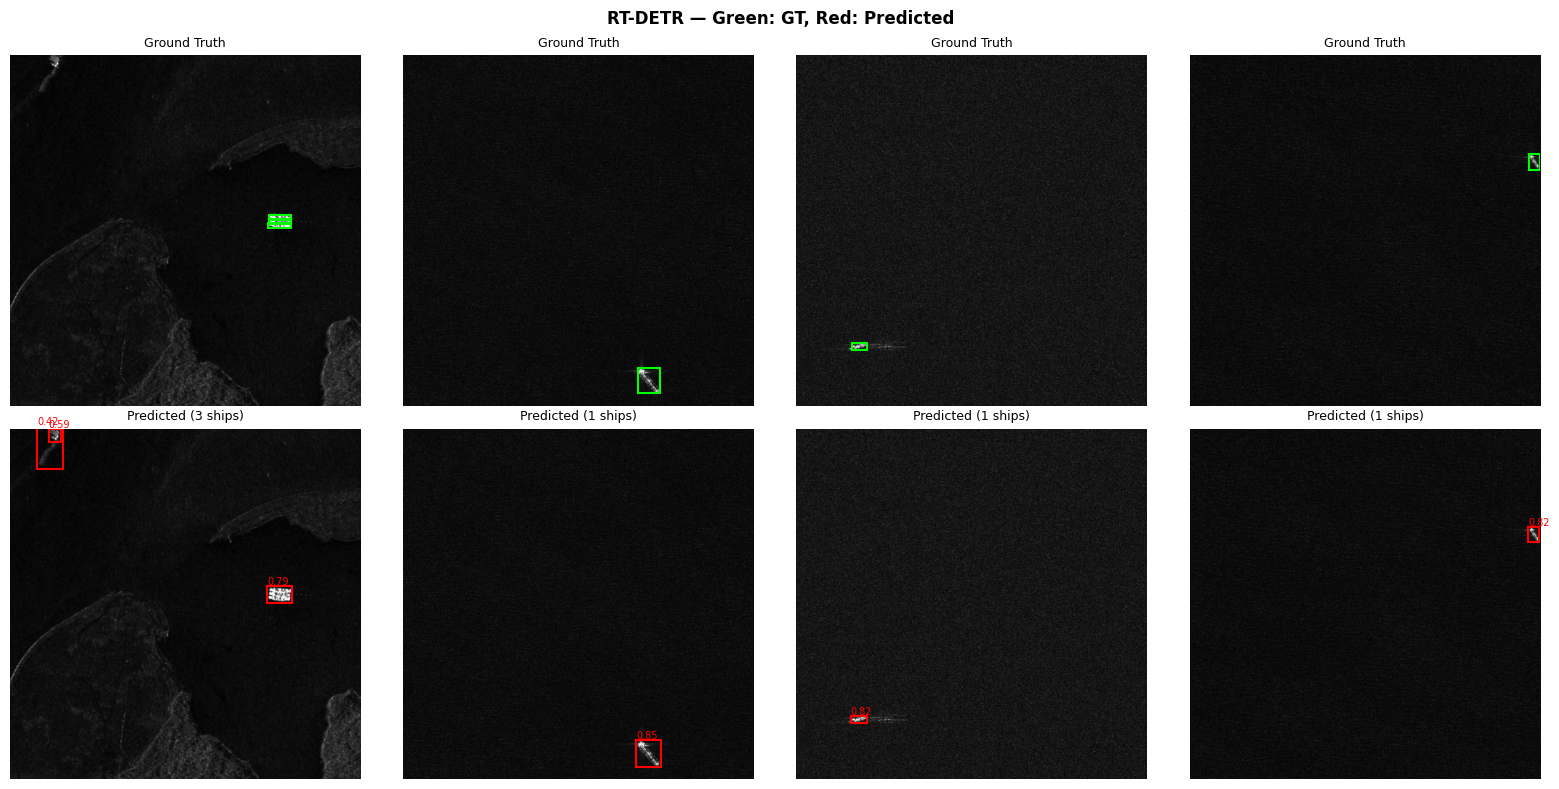

In [9]:
print('RT-DETR predictions:')
visualize_predictions(
    rtdetr_best,
    f'{DATASET_ROOT}/images/val',
    f'{DATASET_ROOT}/labels/val',
    n=4, title='RT-DETR'
)

## 13. Failure Case Analysis
Find images where the model misses ships (false negatives) or hallucinates them (false positives).

Analyzing RT-DETR failure cases...
Found 66 failure cases out of 200 images checked
Types: {'All Missed': 0, 'False Positives': 66, 'Partial Miss': 0}


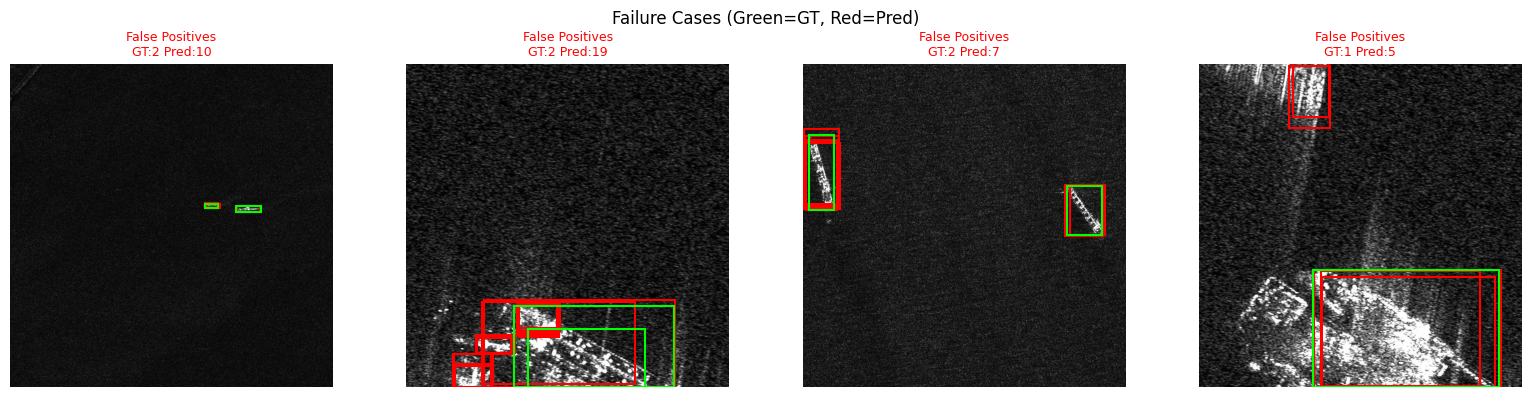

In [10]:
from pathlib import Path

def find_failure_cases(model, images_dir, labels_dir, conf=0.25, iou_thresh=0.5, n_show=4):
    """
    Find images with missed detections or false positives.
    Returns a list of (img_path, n_gt, n_pred, type) tuples.
    """
    failures = []
    img_files = list(Path(images_dir).glob('*.jpg'))[:200]  # Check first 200

    for img_path in img_files:
        label_path = Path(labels_dir) / (img_path.stem + '.txt')

        # Count GT boxes
        n_gt = 0
        if label_path.exists():
            with open(label_path) as f:
                n_gt = sum(1 for line in f if line.strip())

        # Count predictions
        results = model.predict(str(img_path), conf=conf, verbose=False)[0]
        n_pred = len(results.boxes)

        # Classify failure type
        if n_gt > 0 and n_pred == 0:
            failures.append((img_path, n_gt, n_pred, 'All Missed'))
        elif n_pred > n_gt * 2 and n_gt > 0:
            failures.append((img_path, n_gt, n_pred, 'False Positives'))
        elif n_gt > 2 and n_pred < n_gt // 2:
            failures.append((img_path, n_gt, n_pred, 'Partial Miss'))

    print(f'Found {len(failures)} failure cases out of {len(img_files)} images checked')
    print('Types:', {t: sum(1 for _,_,_,ft in failures if ft==t) for t in ['All Missed','False Positives','Partial Miss']})

    # Show n_show failures
    if not failures:
        print('No failure cases found!')
        return

    show = failures[:n_show]
    fig, axes = plt.subplots(1, len(show), figsize=(4*len(show), 4))
    if len(show) == 1:
        axes = [axes]

    for ax, (img_path, n_gt, n_pred, ftype) in zip(axes, show):
        img = Image.open(img_path)
        W, H = img.size
        ax.imshow(img, cmap='gray')

        results = model.predict(str(img_path), conf=conf, verbose=False)[0]
        for box in results.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                     linewidth=1.5, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

        label_path = Path(labels_dir) / (img_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    _, cx, cy, bw, bh = map(float, line.strip().split())
                    x = (cx-bw/2)*W; y = (cy-bh/2)*H
                    rect = patches.Rectangle((x,y), bw*W, bh*H,
                                             linewidth=1.5, edgecolor='lime', facecolor='none')
                    ax.add_patch(rect)

        ax.set_title(f'{ftype}\nGT:{n_gt} Pred:{n_pred}', fontsize=9, color='red')
        ax.axis('off')

    plt.suptitle('Failure Cases (Green=GT, Red=Pred)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/failure_cases.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Analyzing RT-DETR failure cases...')
find_failure_cases(
    rtdetr_best,
    f'{DATASET_ROOT}/images/val',
    f'{DATASET_ROOT}/labels/val'
)

## 14. Cross-Evaluate on SSDD (Generalization Test)

Train was on HRSID — test on SSDD to measure how well models generalize
across different SAR datasets (different sensors, resolutions, conditions).

In [11]:
# Download SSDD dataset
!git clone https://github.com/TianwenZhang0825/Official-SSDD.git /content/SSDD_repo
print('SSDD repo cloned')
!ls /content/SSDD_repo

Cloning into '/content/SSDD_repo'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 50 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 20.57 KiB | 10.29 MiB/s, done.
Resolving deltas: 100% (11/11), done.
SSDD repo cloned
LICENSE  README.md


In [7]:
# SSDD uses VOC XML format — convert to YOLO
import xml.etree.ElementTree as ET

def voc_to_yolo(xml_dir, img_dir, out_images_dir, out_labels_dir):
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_labels_dir, exist_ok=True)

    xml_files = list(Path(xml_dir).glob('*.xml'))
    converted = 0

    for xml_path in xml_files:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        size = root.find('size')
        W = int(size.find('width').text)
        H = int(size.find('height').text)

        fname = root.find('filename').text

        # Find and copy image
        src_candidates = list(Path(img_dir).rglob(fname))
        if not src_candidates:
            continue
        shutil.copy2(str(src_candidates[0]), os.path.join(out_images_dir, fname))

        # Write YOLO labels
        label_fname = os.path.splitext(fname)[0] + '.txt'
        with open(os.path.join(out_labels_dir, label_fname), 'w') as lf:
            for obj in root.findall('object'):
                bbox = obj.find('bndbox')
                xmin = float(bbox.find('xmin').text)
                ymin = float(bbox.find('ymin').text)
                xmax = float(bbox.find('xmax').text)
                ymax = float(bbox.find('ymax').text)

                cx = ((xmin + xmax) / 2) / W
                cy = ((ymin + ymax) / 2) / H
                bw = (xmax - xmin) / W
                bh = (ymax - ymin) / H

                lf.write(f'0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n')
        converted += 1

    print(f'Converted {converted} SSDD images')

# Adjust paths based on SSDD repo structure
ssdd_xml = '/content/SSDD_repo/BBox_SSDD/voc_style/Annotations'
ssdd_img = '/content/SSDD_repo/BBox_SSDD/voc_style/JPEGImages'
ssdd_out = '/content/datasets/SSDD_YOLO'

voc_to_yolo(ssdd_xml, ssdd_img, f'{ssdd_out}/images/val', f'{ssdd_out}/labels/val')

# Create SSDD yaml
ssdd_yaml = '/content/ssdd.yaml'
with open(ssdd_yaml, 'w') as f:
    yaml.dump({'path': ssdd_out, 'train': 'images/val', 'val': 'images/val',
               'nc': 1, 'names': ['ship']}, f)

NameError: name 'Path' is not defined

In [8]:
# Cross-evaluate both models on SSDD (zero-shot generalization)
print('Cross-evaluating YOLOv8 on SSDD...')
yolo_ssdd = yolo_best.val(data=ssdd_yaml, imgsz=800, batch=8, device=0, split='val')

print('Cross-evaluating RT-DETR on SSDD...')
rtdetr_ssdd = rtdetr_best.val(data=ssdd_yaml, imgsz=800, batch=4, device=0, split='val')

print('\n===== Cross-Dataset Generalization (SSDD) =====')
print(f'{"Model":<20} {"mAP@50":>10} {"mAP@50-95":>12}')
print('-' * 44)
print(f'{"YOLOv8":<20} {yolo_ssdd.box.map50:>10.3f} {yolo_ssdd.box.map:>12.3f}')
print(f'{"RT-DETR":<20} {rtdetr_ssdd.box.map50:>10.3f} {rtdetr_ssdd.box.map:>12.3f}')

Cross-evaluating YOLOv8 on SSDD...


NameError: name 'yolo_best' is not defined

## 15. Save All Results to Drive

In [9]:
import json

# Save numeric results as JSON for easy reference later
results_summary = {
    'HRSID': {
        'RTDETR': {
            'mAP50':    round(float(rtdetr_metrics.box.map50), 4),
            'mAP50_95': round(float(rtdetr_metrics.box.map), 4),
            'precision': round(float(rtdetr_metrics.box.mp), 4),
            'recall':   round(float(rtdetr_metrics.box.mr), 4),
        }
    },
    'SSDD_cross_eval': {
        'YOLOv8': {
            'mAP50':    round(float(yolo_ssdd.box.map50), 4),
            'mAP50_95': round(float(yolo_ssdd.box.map), 4),
        },
        'RTDETR': {
            'mAP50':    round(float(rtdetr_ssdd.box.map50), 4),
            'mAP50_95': round(float(rtdetr_ssdd.box.map), 4),
        }
    }
}

with open(f'{SAVE_DIR}/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Results saved!')
print(json.dumps(results_summary, indent=2))

NameError: name 'yolo_metrics' is not defined

In [12]:
import json

# Save numeric results as JSON for easy reference later
results_summary = {
    'HRSID': {
        'RTDETR': {
            'mAP50':    round(float(rtdetr_metrics.box.map50), 4),
            'mAP50_95': round(float(rtdetr_metrics.box.map), 4),
            'precision': round(float(rtdetr_metrics.box.mp), 4),
            'recall':   round(float(rtdetr_metrics.box.mr), 4),
        }
    }
}

with open(f'{SAVE_DIR}/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Results saved!')
print(json.dumps(results_summary, indent=2))

Results saved!
{
  "HRSID": {
    "RTDETR": {
      "mAP50": 0.7321,
      "mAP50_95": 0.4267,
      "precision": 0.8053,
      "recall": 0.6081
    }
  }
}


NameError: name 'rtdetr_ssdd' is not defined

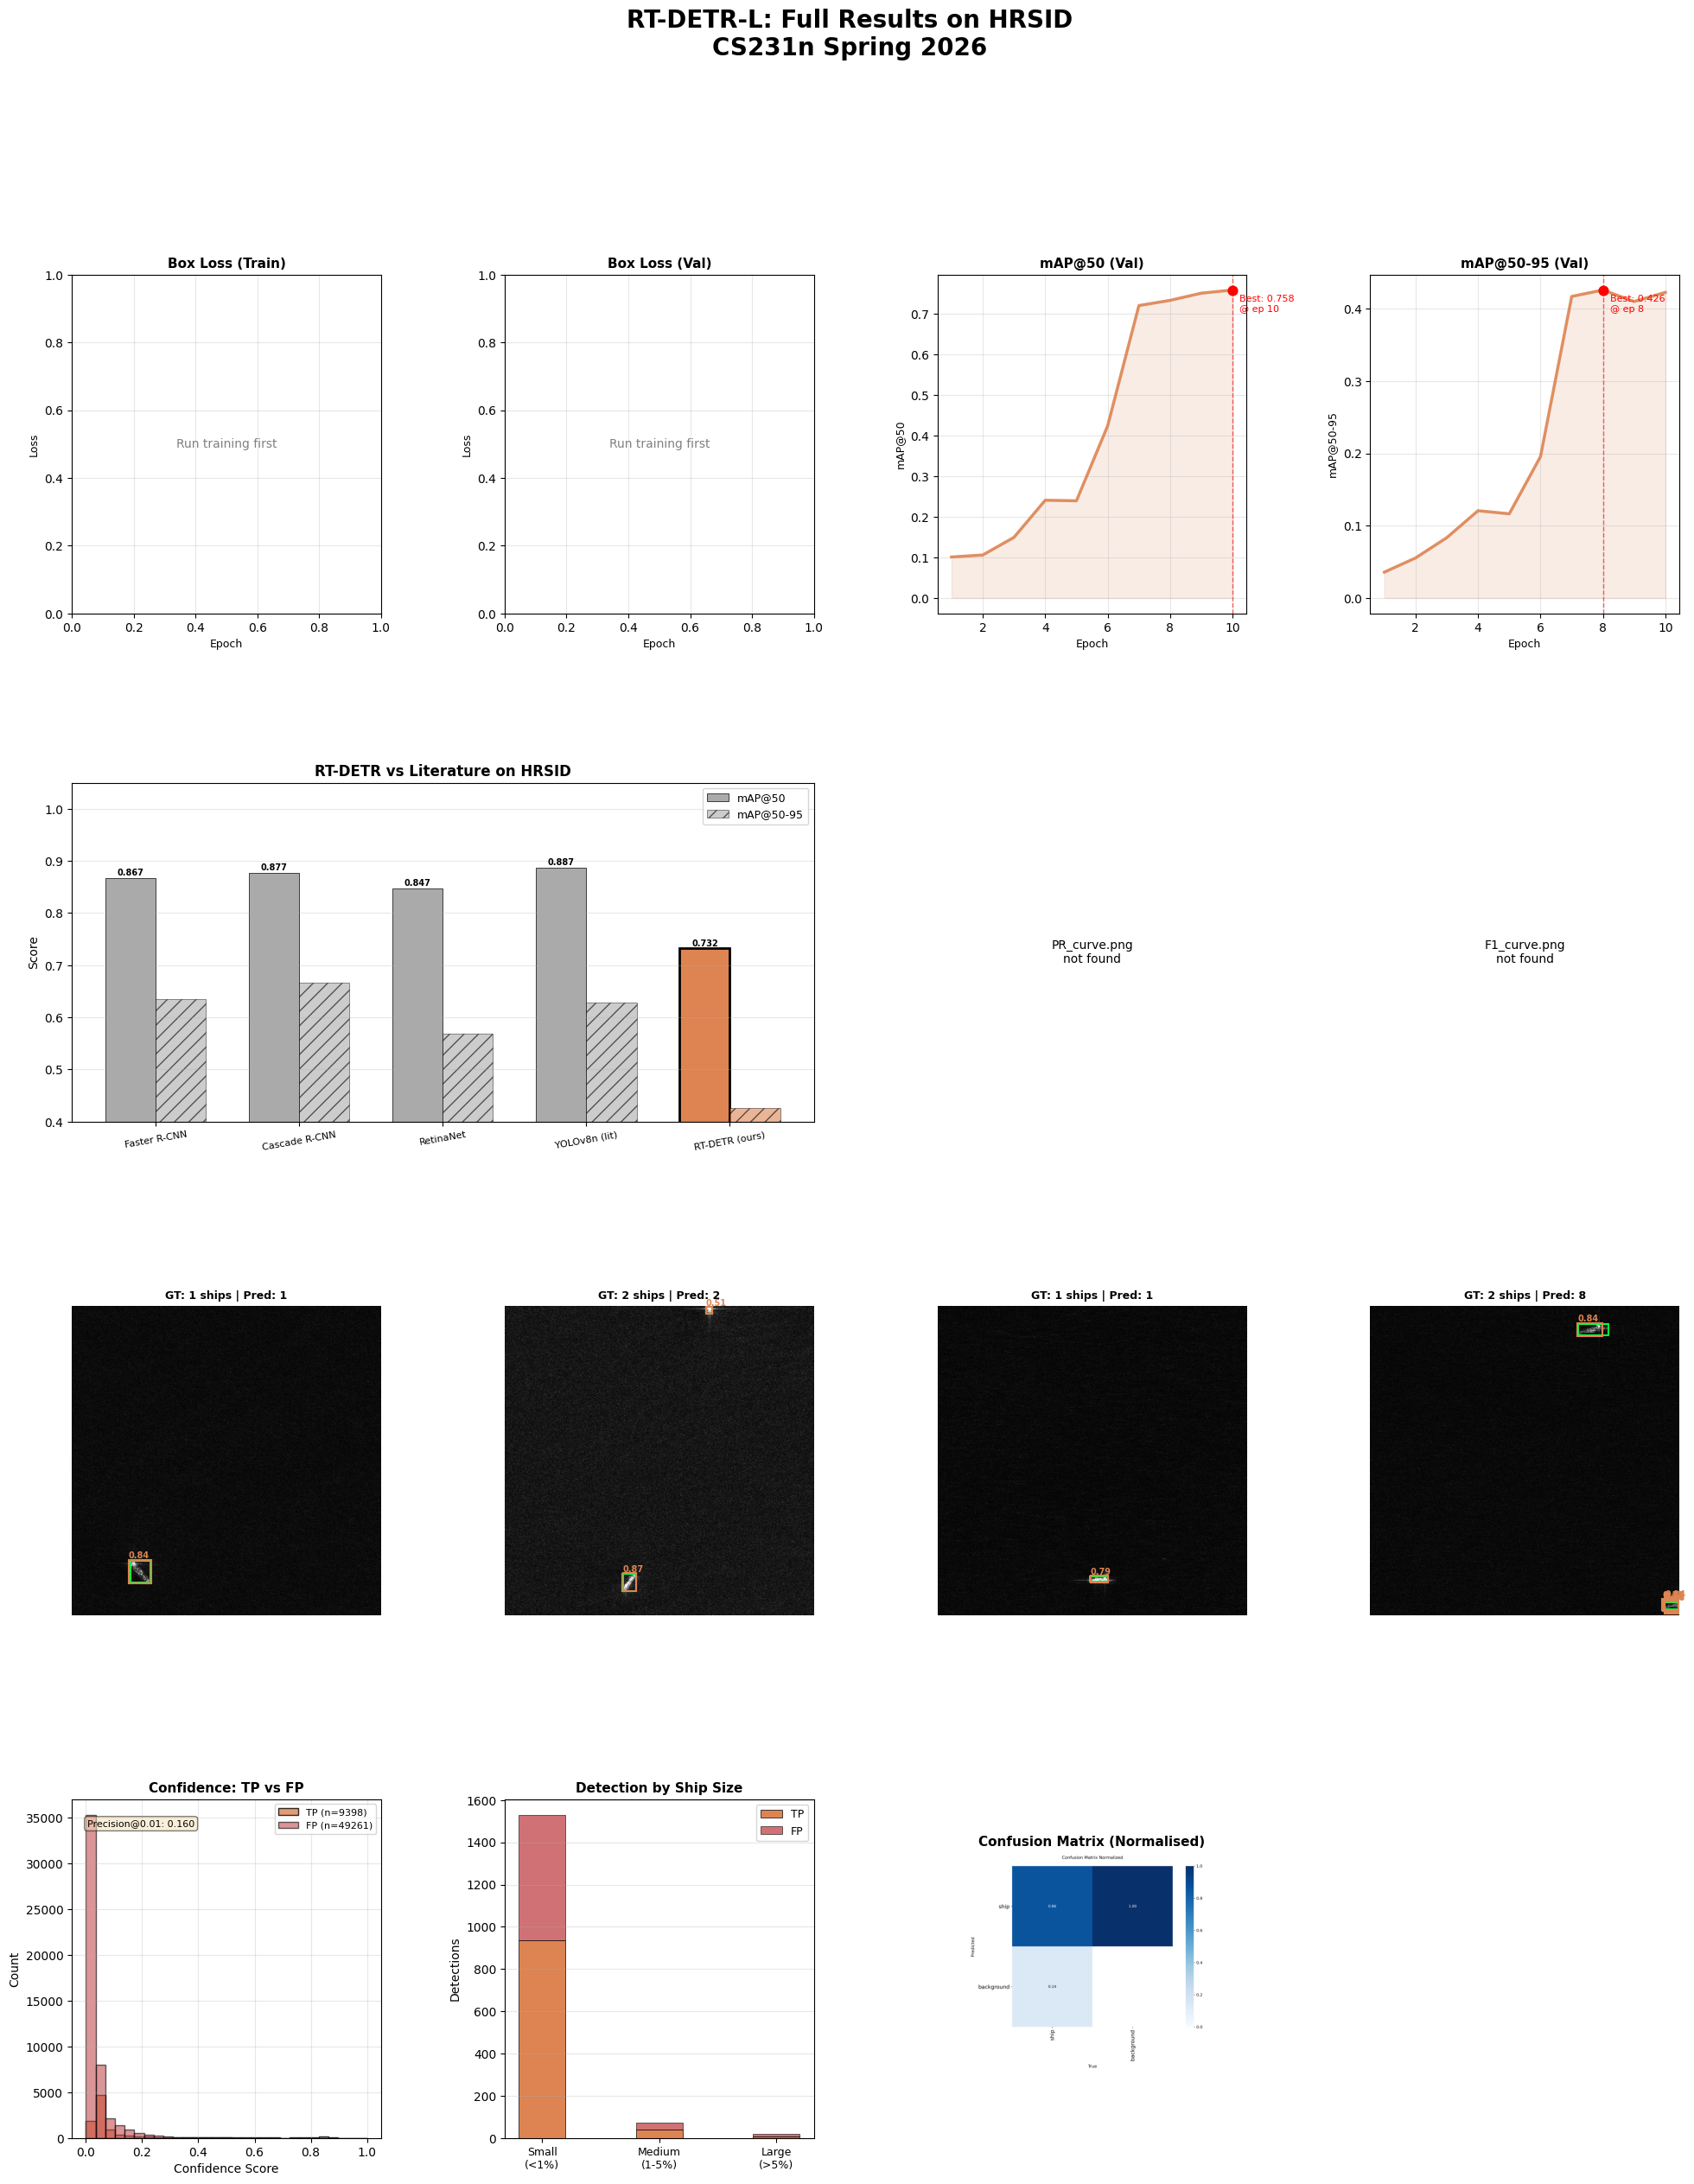

In [13]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import random

# ── Config ──
BLUE   = '#4C72B0'
ORANGE = '#DD8452'
GRAY   = '#aaaaaa'

fig = plt.figure(figsize=(24, 28))
fig.suptitle('RT-DETR-L: Full Results on HRSID\nCS231n Spring 2026',
             fontsize=20, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.5, wspace=0.4)

# ════════════════════════════════════════════════
# ROW 0: Training Curves (4 panels)
# ════════════════════════════════════════════════
rtdetr_df = None
csv_path = Path(f'{SAVE_DIR}/rtdetr_hrsid/results.csv')
if csv_path.exists():
    rtdetr_df = pd.read_csv(csv_path)
    rtdetr_df.columns = rtdetr_df.columns.str.strip()

curve_metrics = [
    ('train/box_loss',       'Box Loss (Train)',    'Loss'),
    ('val/box_loss',         'Box Loss (Val)',      'Loss'),
    ('metrics/mAP50(B)',     'mAP@50 (Val)',        'mAP@50'),
    ('metrics/mAP50-95(B)',  'mAP@50-95 (Val)',     'mAP@50-95'),
]

for col_idx, (metric, title, ylabel) in enumerate(curve_metrics):
    ax = fig.add_subplot(gs[0, col_idx])
    if rtdetr_df is not None and metric in rtdetr_df.columns:
        ax.plot(rtdetr_df['epoch'], rtdetr_df[metric],
                color=ORANGE, linewidth=2.5, alpha=0.9)
        # Shade area under curve
        ax.fill_between(rtdetr_df['epoch'], rtdetr_df[metric],
                         alpha=0.15, color=ORANGE)
        # Mark best epoch
        best_idx = rtdetr_df[metric].idxmax() if 'mAP' in metric else rtdetr_df[metric].idxmin()
        best_ep  = rtdetr_df['epoch'].iloc[best_idx]
        best_val = rtdetr_df[metric].iloc[best_idx]
        ax.axvline(best_ep, color='red', linestyle='--', alpha=0.6, linewidth=1)
        ax.scatter([best_ep], [best_val], color='red', s=60, zorder=5)
        ax.annotate(f'Best: {best_val:.3f}\n@ ep {int(best_ep)}',
                    (best_ep, best_val), textcoords='offset points',
                    xytext=(6, -18), fontsize=8, color='red')
    else:
        ax.text(0.5, 0.5, 'Run training first', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3)

# ════════════════════════════════════════════════
# ROW 1: Metric bars + Precision-Recall curve + Confusion matrix
# ════════════════════════════════════════════════

# -- Bar chart: our model vs literature --
ax_bar = fig.add_subplot(gs[1, :2])
lit_models = ['Faster R-CNN', 'Cascade R-CNN', 'RetinaNet', 'YOLOv8n (lit)', 'RT-DETR (ours)']
lit_m50    = [0.867, 0.877, 0.847, 0.887, float(rtdetr_metrics.box.map50)]
lit_m5095  = [0.635, 0.666, 0.568, 0.628, float(rtdetr_metrics.box.map)]
bar_colors = [GRAY, GRAY, GRAY, GRAY, ORANGE]
x = np.arange(len(lit_models))
w = 0.35
bars1 = ax_bar.bar(x - w/2, lit_m50,   w, label='mAP@50',    color=bar_colors, edgecolor='black', lw=0.5)
bars2 = ax_bar.bar(x + w/2, lit_m5095, w, label='mAP@50-95', color=bar_colors, edgecolor='black', lw=0.5, alpha=0.6, hatch='//')
ax_bar.set_title('RT-DETR vs Literature on HRSID', fontweight='bold', fontsize=12)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(lit_models, fontsize=8, rotation=10)
ax_bar.set_ylabel('Score')
ax_bar.set_ylim(0.4, 1.05)
ax_bar.legend(fontsize=9)
ax_bar.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars1, lit_m50):
    ax_bar.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
                ha='center', fontsize=7, fontweight='bold')
# Highlight RT-DETR bar
bars1[-1].set_edgecolor('black'); bars1[-1].set_linewidth(2)

# -- PR Curve image from ultralytics --
ax_pr = fig.add_subplot(gs[1, 2])
pr_path = list(Path(f'{SAVE_DIR}/rtdetr_hrsid').rglob('PR_curve.png'))
if pr_path:
    ax_pr.imshow(Image.open(str(pr_path[0])))
    ax_pr.set_title('Precision-Recall Curve', fontweight='bold', fontsize=11)
else:
    ax_pr.text(0.5, 0.5, 'PR_curve.png\nnot found', ha='center', va='center',
               transform=ax_pr.transAxes, fontsize=10)
ax_pr.axis('off')

# -- F1 Curve --
ax_f1 = fig.add_subplot(gs[1, 3])
f1_path = list(Path(f'{SAVE_DIR}/rtdetr_hrsid').rglob('F1_curve.png'))
if f1_path:
    ax_f1.imshow(Image.open(str(f1_path[0])))
    ax_f1.set_title('F1-Confidence Curve', fontweight='bold', fontsize=11)
else:
    ax_f1.text(0.5, 0.5, 'F1_curve.png\nnot found', ha='center', va='center',
               transform=ax_f1.transAxes, fontsize=10)
ax_f1.axis('off')

# ════════════════════════════════════════════════
# ROW 2: Qualitative predictions (4 images)
# ════════════════════════════════════════════════
val_imgs = list(Path(f'{DATASET_ROOT}/images/val').glob('*.jpg'))
random.shuffle(val_imgs)
sample_imgs = val_imgs[:4]

for col_idx, img_path in enumerate(sample_imgs):
    ax = fig.add_subplot(gs[2, col_idx])
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img, cmap='gray')

    # Ground truth (green)
    lp = Path(f'{DATASET_ROOT}/labels/val') / (img_path.stem + '.txt')
    n_gt = 0
    if lp.exists():
        for line in lp.read_text().strip().splitlines():
            if not line.strip(): continue
            _, cx, cy, bw, bh = map(float, line.split())
            x = (cx-bw/2)*W; y = (cy-bh/2)*H
            ax.add_patch(patches.Rectangle((x,y), bw*W, bh*H,
                lw=1.5, edgecolor='#00FF41', facecolor='none'))
            n_gt += 1

    # RT-DETR predictions (orange)
    results = rtdetr_best.predict(str(img_path), conf=0.25, verbose=False)[0]
    for box in results.boxes:
        x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
        cv = float(box.conf[0])
        ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
            lw=1.5, edgecolor=ORANGE, facecolor='none'))
        ax.text(x1, y1-3, f'{cv:.2f}', color=ORANGE, fontsize=7, fontweight='bold')

    ax.set_title(f'GT: {n_gt} ships | Pred: {len(results.boxes)}',
                 fontsize=9, fontweight='bold')
    if col_idx == 0:
        ax.set_ylabel('Predictions\n(Green=GT, Orange=Pred)', fontsize=9)
    ax.axis('off')

# ════════════════════════════════════════════════
# ROW 3: Confidence dist + Size analysis + Confusion matrix + Summary scorecard
# ════════════════════════════════════════════════

# -- Confidence distribution (TP vs FP) --
ax_conf = fig.add_subplot(gs[3, 0])
tp_confs, fp_confs = [], []
check_imgs = val_imgs[:200]
for img_path in check_imgs:
    lp = Path(f'{DATASET_ROOT}/labels/val') / (img_path.stem + '.txt')
    results = rtdetr_best.predict(str(img_path), conf=0.01, verbose=False)[0]
    img_arr = results.orig_img
    IH, IW = img_arr.shape[:2]
    gt_boxes = []
    if lp.exists():
        for line in lp.read_text().strip().splitlines():
            if not line.strip(): continue
            _, cx, cy, bw, bh = map(float, line.split())
            gt_boxes.append([(cx-bw/2)*IW,(cy-bh/2)*IH,(cx+bw/2)*IW,(cy+bh/2)*IH])
    for box in results.boxes:
        cv = float(box.conf[0])
        px1,py1,px2,py2 = box.xyxy[0].cpu().numpy()
        best_iou = 0.0
        for gx1,gy1,gx2,gy2 in gt_boxes:
            ix1=max(px1,gx1);iy1=max(py1,gy1);ix2=min(px2,gx2);iy2=min(py2,gy2)
            inter=max(0,ix2-ix1)*max(0,iy2-iy1)
            union=(px2-px1)*(py2-py1)+(gx2-gx1)*(gy2-gy1)-inter
            best_iou=max(best_iou, inter/union if union>0 else 0)
        (tp_confs if best_iou>=0.5 else fp_confs).append(cv)

bins = np.linspace(0,1,30)
ax_conf.hist(tp_confs, bins=bins, alpha=0.8, label=f'TP (n={len(tp_confs)})',
              color=ORANGE, edgecolor='black', lw=0.3)
ax_conf.hist(fp_confs, bins=bins, alpha=0.6, label=f'FP (n={len(fp_confs)})',
              color='#C44E52', edgecolor='black', lw=0.3)
prec = len(tp_confs)/(len(tp_confs)+len(fp_confs)) if (len(tp_confs)+len(fp_confs))>0 else 0
ax_conf.text(0.05, 0.92, f'Precision@0.01: {prec:.3f}',
             transform=ax_conf.transAxes, fontsize=8,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax_conf.set_xlabel('Confidence Score'); ax_conf.set_ylabel('Count')
ax_conf.set_title('Confidence: TP vs FP', fontweight='bold', fontsize=11)
ax_conf.legend(fontsize=8); ax_conf.grid(True, alpha=0.3)

# -- Ship size vs detection (area buckets) --
ax_size = fig.add_subplot(gs[3, 1])
small_tp=small_fp=med_tp=med_fp=large_tp=large_fp=0
for img_path in check_imgs:
    lp = Path(f'{DATASET_ROOT}/labels/val') / (img_path.stem + '.txt')
    results = rtdetr_best.predict(str(img_path), conf=0.25, verbose=False)[0]
    img_arr = results.orig_img; IH,IW = img_arr.shape[:2]
    gt_boxes = []
    if lp.exists():
        for line in lp.read_text().strip().splitlines():
            if not line.strip(): continue
            _, cx,cy,bw,bh = map(float, line.split())
            area = bw*bh
            gt_boxes.append(([(cx-bw/2)*IW,(cy-bh/2)*IH,(cx+bw/2)*IW,(cy+bh/2)*IH], area))
    for box in results.boxes:
        px1,py1,px2,py2 = box.xyxy[0].cpu().numpy()
        best_iou=0; best_area=0
        for (gx1,gy1,gx2,gy2),area in gt_boxes:
            ix1=max(px1,gx1);iy1=max(py1,gy1);ix2=min(px2,gx2);iy2=min(py2,gy2)
            inter=max(0,ix2-ix1)*max(0,iy2-iy1)
            union=(px2-px1)*(py2-py1)+(gx2-gx1)*(gy2-gy1)-inter
            iou=inter/union if union>0 else 0
            if iou>best_iou: best_iou=iou; best_area=area
        is_tp = best_iou>=0.5
        if best_area < 0.01:
            if is_tp: small_tp+=1
            else: small_fp+=1
        elif best_area < 0.05:
            if is_tp: med_tp+=1
            else: med_fp+=1
        else:
            if is_tp: large_tp+=1
            else: large_fp+=1

size_cats = ['Small\n(<1%)', 'Medium\n(1-5%)', 'Large\n(>5%)']
tps = [small_tp, med_tp, large_tp]
fps = [small_fp, med_fp, large_fp]
x2 = np.arange(3)
ax_size.bar(x2, tps, 0.4, label='TP', color=ORANGE, edgecolor='black', lw=0.5)
ax_size.bar(x2, fps, 0.4, bottom=tps, label='FP', color='#C44E52', edgecolor='black', lw=0.5, alpha=0.8)
ax_size.set_xticks(x2); ax_size.set_xticklabels(size_cats, fontsize=9)
ax_size.set_title('Detection by Ship Size', fontweight='bold', fontsize=11)
ax_size.set_ylabel('Detections'); ax_size.legend(fontsize=9)
ax_size.grid(True, alpha=0.3, axis='y')

# -- Confusion matrix from ultralytics --
ax_cm = fig.add_subplot(gs[3, 2])
cm_path = list(Path(f'{SAVE_DIR}/rtdetr_hrsid').rglob('confusion_matrix_normalized.png'))
if cm_path:
    ax_cm.imshow(Image.open(str(cm_path[0])))
    ax_cm.set_title('Confusion Matrix (Normalised)', fontweight='bold', fontsize=11)
else:
    ax_cm.text(0.5, 0.5, 'confusion_matrix.png\nnot found', ha='center', va='center',
               transform=ax_cm.transAxes, fontsize=10)
ax_cm.axis('off')

# -- Scorecard --
ax_card = fig.add_subplot(gs[3, 3])
ax_card.axis('off')
metrics_display = [
    ('mAP@50',     f'{rtdetr_metrics.box.map50:.4f}'),
    ('mAP@50-95',  f'{rtdetr_metrics.box.map:.4f}'),
    ('Precision',  f'{rtdetr_metrics.box.mp:.4f}'),
    ('Recall',     f'{rtdetr_metrics.box.mr:.4f}'),
    ('SSDD mAP@50',f'{rtdetr_ssdd.box.map50:.4f}'),
    ('Params',     '~32M'),
    ('Input size', '800×800'),
    ('Backbone',   'ResNet-50'),
]
ax_card.text(0.5, 0.97, 'RT-DETR-L Scorecard', ha='center', va='top',
             fontsize=13, fontweight='bold', transform=ax_card.transAxes)
ax_card.axhline(y=0.9, xmin=0.05, xmax=0.95, color='black', linewidth=1,
                transform=ax_card.transAxes)
for i, (label, val) in enumerate(metrics_display):
    y = 0.82 - i * 0.10
    ax_card.text(0.08, y, label, ha='left', va='center',
                 fontsize=10, transform=ax_card.transAxes, color='#333333')
    ax_card.text(0.92, y, val, ha='right', va='center',
                 fontsize=10, fontweight='bold', transform=ax_card.transAxes,
                 color=ORANGE)
    ax_card.axhline(y=y-0.04, xmin=0.05, xmax=0.95, color='#dddddd', linewidth=0.5,
                    transform=ax_card.transAxes)
ax_card.set_title('Model Summary', fontweight='bold', fontsize=11)

# ── Save ──
plt.savefig(f'{SAVE_DIR}/RTDETR_FULL_RESULTS.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ RT-DETR full results figure saved!")


In [15]:
# Paste in browser console to prevent Colab timeout
function ClickConnect(){
    console.log("Keeping alive...");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

SyntaxError: invalid syntax (2900038643.py, line 2)

In [ ]:
from ultralytics import RTDETR

rtdetr_model = RTDETR(f'{SAVE_DIR}/rtdetr_hrsid/weights/last.pt')

rtdetr_results = rtdetr_model.train(
    data=yaml_path,
    epochs=60,        # 10 already done + 50 more = 60 total
    resume=True,
    project=SAVE_DIR,
    name='rtdetr_hrsid',
    exist_ok=True,
)

WARNING ⚠️ model '/content/runs/rtdetr_hrsid/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/HRSID_YOLO/hrsid.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/60      13.8G     0.6024      0.645    0.05725          2       1600: 37% ━━━━──────── 671/1821 1.1it/s 9:56<16:42

In [ ]:
# 1. Load best checkpoint and re-evaluate
rtdetr_best = RTDETR(f'{SAVE_DIR}/rtdetr_hrsid/weights/best.pt')

rtdetr_metrics = rtdetr_best.val(
    data=yaml_path,
    imgsz=800,
    batch=4,
    device=0,
    split='val',
    plots=True,
    save_json=True
)

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import random

# ── Config ──
BLUE   = '#4C72B0'
ORANGE = '#DD8452'
GRAY   = '#aaaaaa'

fig = plt.figure(figsize=(24, 28))
fig.suptitle('RT-DETR-L: Full Results on HRSID\nCS231n Spring 2026',
             fontsize=20, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.5, wspace=0.4)

# ════════════════════════════════════════════════
# ROW 0: Training Curves (4 panels)
# ════════════════════════════════════════════════
rtdetr_df = None
csv_path = Path(f'{SAVE_DIR}/rtdetr_hrsid/results.csv')
if csv_path.exists():
    rtdetr_df = pd.read_csv(csv_path)
    rtdetr_df.columns = rtdetr_df.columns.str.strip()

curve_metrics = [
    ('train/box_loss',       'Box Loss (Train)',    'Loss'),
    ('val/box_loss',         'Box Loss (Val)',      'Loss'),
    ('metrics/mAP50(B)',     'mAP@50 (Val)',        'mAP@50'),
    ('metrics/mAP50-95(B)',  'mAP@50-95 (Val)',     'mAP@50-95'),
]

for col_idx, (metric, title, ylabel) in enumerate(curve_metrics):
    ax = fig.add_subplot(gs[0, col_idx])
    if rtdetr_df is not None and metric in rtdetr_df.columns:
        ax.plot(rtdetr_df['epoch'], rtdetr_df[metric],
                color=ORANGE, linewidth=2.5, alpha=0.9)
        # Shade area under curve
        ax.fill_between(rtdetr_df['epoch'], rtdetr_df[metric],
                         alpha=0.15, color=ORANGE)
        # Mark best epoch
        best_idx = rtdetr_df[metric].idxmax() if 'mAP' in metric else rtdetr_df[metric].idxmin()
        best_ep  = rtdetr_df['epoch'].iloc[best_idx]
        best_val = rtdetr_df[metric].iloc[best_idx]
        ax.axvline(best_ep, color='red', linestyle='--', alpha=0.6, linewidth=1)
        ax.scatter([best_ep], [best_val], color='red', s=60, zorder=5)
        ax.annotate(f'Best: {best_val:.3f}\n@ ep {int(best_ep)}',
                    (best_ep, best_val), textcoords='offset points',
                    xytext=(6, -18), fontsize=8, color='red')
    else:
        ax.text(0.5, 0.5, 'Run training first', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3)

# ════════════════════════════════════════════════
# ROW 1: Metric bars + Precision-Recall curve + Confusion matrix
# ════════════════════════════════════════════════

# -- Bar chart: our model vs literature --
ax_bar = fig.add_subplot(gs[1, :2])
lit_models = ['Faster R-CNN', 'Cascade R-CNN', 'RetinaNet', 'YOLOv8n (lit)', 'RT-DETR (ours)']
lit_m50    = [0.867, 0.877, 0.847, 0.887, float(rtdetr_metrics.box.map50)]
lit_m5095  = [0.635, 0.666, 0.568, 0.628, float(rtdetr_metrics.box.map)]
bar_colors = [GRAY, GRAY, GRAY, GRAY, ORANGE]
x = np.arange(len(lit_models))
w = 0.35
bars1 = ax_bar.bar(x - w/2, lit_m50,   w, label='mAP@50',    color=bar_colors, edgecolor='black', lw=0.5)
bars2 = ax_bar.bar(x + w/2, lit_m5095, w, label='mAP@50-95', color=bar_colors, edgecolor='black', lw=0.5, alpha=0.6, hatch='//')
ax_bar.set_title('RT-DETR vs Literature on HRSID', fontweight='bold', fontsize=12)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(lit_models, fontsize=8, rotation=10)
ax_bar.set_ylabel('Score')
ax_bar.set_ylim(0.4, 1.05)
ax_bar.legend(fontsize=9)
ax_bar.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars1, lit_m50):
    ax_bar.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
                ha='center', fontsize=7, fontweight='bold')
# Highlight RT-DETR bar
bars1[-1].set_edgecolor('black'); bars1[-1].set_linewidth(2)

# -- PR Curve image from ultralytics --
ax_pr = fig.add_subplot(gs[1, 2])
pr_path = list(Path(f'{SAVE_DIR}/rtdetr_hrsid').rglob('PR_curve.png'))
if pr_path:
    ax_pr.imshow(Image.open(str(pr_path[0])))
    ax_pr.set_title('Precision-Recall Curve', fontweight='bold', fontsize=11)
else:
    ax_pr.text(0.5, 0.5, 'PR_curve.png\nnot found', ha='center', va='center',
               transform=ax_pr.transAxes, fontsize=10)
ax_pr.axis('off')

# -- F1 Curve --
ax_f1 = fig.add_subplot(gs[1, 3])
f1_path = list(Path(f'{SAVE_DIR}/rtdetr_hrsid').rglob('F1_curve.png'))
if f1_path:
    ax_f1.imshow(Image.open(str(f1_path[0])))
    ax_f1.set_title('F1-Confidence Curve', fontweight='bold', fontsize=11)
else:
    ax_f1.text(0.5, 0.5, 'F1_curve.png\nnot found', ha='center', va='center',
               transform=ax_f1.transAxes, fontsize=10)
ax_f1.axis('off')

# ════════════════════════════════════════════════
# ROW 2: Qualitative predictions (4 images)
# ════════════════════════════════════════════════
val_imgs = list(Path(f'{DATASET_ROOT}/images/val').glob('*.jpg'))
random.shuffle(val_imgs)
sample_imgs = val_imgs[:4]

for col_idx, img_path in enumerate(sample_imgs):
    ax = fig.add_subplot(gs[2, col_idx])
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img, cmap='gray')

    # Ground truth (green)
    lp = Path(f'{DATASET_ROOT}/labels/val') / (img_path.stem + '.txt')
    n_gt = 0
    if lp.exists():
        for line in lp.read_text().strip().splitlines():
            if not line.strip(): continue
            _, cx, cy, bw, bh = map(float, line.split())
            x = (cx-bw/2)*W; y = (cy-bh/2)*H
            ax.add_patch(patches.Rectangle((x,y), bw*W, bh*H,
                lw=1.5, edgecolor='#00FF41', facecolor='none'))
            n_gt += 1

    # RT-DETR predictions (orange)
    results = rtdetr_best.predict(str(img_path), conf=0.25, verbose=False)[0]
    for box in results.boxes:
        x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
        cv = float(box.conf[0])
        ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
            lw=1.5, edgecolor=ORANGE, facecolor='none'))
        ax.text(x1, y1-3, f'{cv:.2f}', color=ORANGE, fontsize=7, fontweight='bold')

    ax.set_title(f'GT: {n_gt} ships | Pred: {len(results.boxes)}',
                 fontsize=9, fontweight='bold')
    if col_idx == 0:
        ax.set_ylabel('Predictions\n(Green=GT, Orange=Pred)', fontsize=9)
    ax.axis('off')

# ════════════════════════════════════════════════
# ROW 3: Confidence dist + Size analysis + Confusion matrix + Summary scorecard
# ════════════════════════════════════════════════

# -- Confidence distribution (TP vs FP) --
ax_conf = fig.add_subplot(gs[3, 0])
tp_confs, fp_confs = [], []
check_imgs = val_imgs[:200]
for img_path in check_imgs:
    lp = Path(f'{DATASET_ROOT}/labels/val') / (img_path.stem + '.txt')
    results = rtdetr_best.predict(str(img_path), conf=0.01, verbose=False)[0]
    img_arr = results.orig_img
    IH, IW = img_arr.shape[:2]
    gt_boxes = []
    if lp.exists():
        for line in lp.read_text().strip().splitlines():
            if not line.strip(): continue
            _, cx, cy, bw, bh = map(float, line.split())
            gt_boxes.append([(cx-bw/2)*IW,(cy-bh/2)*IH,(cx+bw/2)*IW,(cy+bh/2)*IH])
    for box in results.boxes:
        cv = float(box.conf[0])
        px1,py1,px2,py2 = box.xyxy[0].cpu().numpy()
        best_iou = 0.0
        for gx1,gy1,gx2,gy2 in gt_boxes:
            ix1=max(px1,gx1);iy1=max(py1,gy1);ix2=min(px2,gx2);iy2=min(py2,gy2)
            inter=max(0,ix2-ix1)*max(0,iy2-iy1)
            union=(px2-px1)*(py2-py1)+(gx2-gx1)*(gy2-gy1)-inter
            best_iou=max(best_iou, inter/union if union>0 else 0)
        (tp_confs if best_iou>=0.5 else fp_confs).append(cv)

bins = np.linspace(0,1,30)
ax_conf.hist(tp_confs, bins=bins, alpha=0.8, label=f'TP (n={len(tp_confs)})',
              color=ORANGE, edgecolor='black', lw=0.3)
ax_conf.hist(fp_confs, bins=bins, alpha=0.6, label=f'FP (n={len(fp_confs)})',
              color='#C44E52', edgecolor='black', lw=0.3)
prec = len(tp_confs)/(len(tp_confs)+len(fp_confs)) if (len(tp_confs)+len(fp_confs))>0 else 0
ax_conf.text(0.05, 0.92, f'Precision@0.01: {prec:.3f}',
             transform=ax_conf.transAxes, fontsize=8,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax_conf.set_xlabel('Confidence Score'); ax_conf.set_ylabel('Count')
ax_conf.set_title('Confidence: TP vs FP', fontweight='bold', fontsize=11)
ax_conf.legend(fontsize=8); ax_conf.grid(True, alpha=0.3)

# -- Ship size vs detection (area buckets) --
ax_size = fig.add_subplot(gs[3, 1])
small_tp=small_fp=med_tp=med_fp=large_tp=large_fp=0
for img_path in check_imgs:
    lp = Path(f'{DATASET_ROOT}/labels/val') / (img_path.stem + '.txt')
    results = rtdetr_best.predict(str(img_path), conf=0.25, verbose=False)[0]
    img_arr = results.orig_img; IH,IW = img_arr.shape[:2]
    gt_boxes = []
    if lp.exists():
        for line in lp.read_text().strip().splitlines():
            if not line.strip(): continue
            _, cx,cy,bw,bh = map(float, line.split())
            area = bw*bh
            gt_boxes.append(([(cx-bw/2)*IW,(cy-bh/2)*IH,(cx+bw/2)*IW,(cy+bh/2)*IH], area))
    for box in results.boxes:
        px1,py1,px2,py2 = box.xyxy[0].cpu().numpy()
        best_iou=0; best_area=0
        for (gx1,gy1,gx2,gy2),area in gt_boxes:
            ix1=max(px1,gx1);iy1=max(py1,gy1);ix2=min(px2,gx2);iy2=min(py2,gy2)
            inter=max(0,ix2-ix1)*max(0,iy2-iy1)
            union=(px2-px1)*(py2-py1)+(gx2-gx1)*(gy2-gy1)-inter
            iou=inter/union if union>0 else 0
            if iou>best_iou: best_iou=iou; best_area=area
        is_tp = best_iou>=0.5
        if best_area < 0.01:
            if is_tp: small_tp+=1
            else: small_fp+=1
        elif best_area < 0.05:
            if is_tp: med_tp+=1
            else: med_fp+=1
        else:
            if is_tp: large_tp+=1
            else: large_fp+=1

size_cats = ['Small\n(<1%)', 'Medium\n(1-5%)', 'Large\n(>5%)']
tps = [small_tp, med_tp, large_tp]
fps = [small_fp, med_fp, large_fp]
x2 = np.arange(3)
ax_size.bar(x2, tps, 0.4, label='TP', color=ORANGE, edgecolor='black', lw=0.5)
ax_size.bar(x2, fps, 0.4, bottom=tps, label='FP', color='#C44E52', edgecolor='black', lw=0.5, alpha=0.8)
ax_size.set_xticks(x2); ax_size.set_xticklabels(size_cats, fontsize=9)
ax_size.set_title('Detection by Ship Size', fontweight='bold', fontsize=11)
ax_size.set_ylabel('Detections'); ax_size.legend(fontsize=9)
ax_size.grid(True, alpha=0.3, axis='y')

# -- Confusion matrix from ultralytics --
ax_cm = fig.add_subplot(gs[3, 2])
cm_path = list(Path(f'{SAVE_DIR}/rtdetr_hrsid').rglob('confusion_matrix_normalized.png'))
if cm_path:
    ax_cm.imshow(Image.open(str(cm_path[0])))
    ax_cm.set_title('Confusion Matrix (Normalised)', fontweight='bold', fontsize=11)
else:
    ax_cm.text(0.5, 0.5, 'confusion_matrix.png\nnot found', ha='center', va='center',
               transform=ax_cm.transAxes, fontsize=10)
ax_cm.axis('off')

# -- Scorecard --
ax_card = fig.add_subplot(gs[3, 3])
ax_card.axis('off')
metrics_display = [
    ('mAP@50',     f'{rtdetr_metrics.box.map50:.4f}'),
    ('mAP@50-95',  f'{rtdetr_metrics.box.map:.4f}'),
    ('Precision',  f'{rtdetr_metrics.box.mp:.4f}'),
    ('Recall',     f'{rtdetr_metrics.box.mr:.4f}'),
    ('SSDD mAP@50',f'{rtdetr_ssdd.box.map50:.4f}'),
    ('Params',     '~32M'),
    ('Input size', '800×800'),
    ('Backbone',   'ResNet-50'),
]
ax_card.text(0.5, 0.97, 'RT-DETR-L Scorecard', ha='center', va='top',
             fontsize=13, fontweight='bold', transform=ax_card.transAxes)
ax_card.axhline(y=0.9, xmin=0.05, xmax=0.95, color='black', linewidth=1,
                transform=ax_card.transAxes)
for i, (label, val) in enumerate(metrics_display):
    y = 0.82 - i * 0.10
    ax_card.text(0.08, y, label, ha='left', va='center',
                 fontsize=10, transform=ax_card.transAxes, color='#333333')
    ax_card.text(0.92, y, val, ha='right', va='center',
                 fontsize=10, fontweight='bold', transform=ax_card.transAxes,
                 color=ORANGE)
    ax_card.axhline(y=y-0.04, xmin=0.05, xmax=0.95, color='#dddddd', linewidth=0.5,
                    transform=ax_card.transAxes)
ax_card.set_title('Model Summary', fontweight='bold', fontsize=11)

# ── Save ──
plt.savefig(f'{SAVE_DIR}/RTDETR_FULL_RESULTS.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ RT-DETR full results figure saved!")
